# 🌳 Ensemble Methods - Beginner's Guide
### Topics: Voting Classifier | Random Forest

---

## 🤔 What is an Ensemble Method?

Imagine you have a **tough exam question**. You're not sure about the answer.

Would you rather:
- ❌ Trust only **one friend's** answer?
- ✅ Ask **5 friends** and go with the **majority answer**?

That's exactly what Ensemble Methods do! Instead of one model, we use **multiple models together** to get a better prediction.

---

## 📚 What We'll Learn Today

| Topic | What it does |
|---|---|
| **Voting Classifier** | Combines different models, takes majority vote |
| **Random Forest** | Combines many Decision Trees using randomness |


---
## 📦 Step 1: Import Libraries

In [9]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Individual models (we'll combine these!)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Ensemble models
from sklearn.ensemble import VotingClassifier, RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 🏥 Step 2: Load the Dataset

We'll use the **Breast Cancer dataset** - a classic beginner dataset.

**Goal**: Predict if a tumor is **Malignant (cancerous)** or **Benign (not cancerous)**

- Input: 30 features (size, shape, texture of tumor cells)
- Output: 0 = Malignant, 1 = Benign

In [10]:
# Load dataset
data = load_breast_cancer()

X = data.data       # Features (tumor measurements)
y = data.target     # Labels (0 = Malignant, 1 = Benign)

# Put into a DataFrame to see it nicely
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(f"📊 Dataset Shape: {X.shape}")
print(f"   → {X.shape[0]} patients, {X.shape[1]} features")
print()
print(f"🔢 Class Distribution:")
print(f"   Malignant (0): {sum(y == 0)} patients")
print(f"   Benign    (1): {sum(y == 1)} patients")
print()
print("📋 First 5 rows:")
df.head()

📊 Dataset Shape: (569, 30)
   → 569 patients, 30 features

🔢 Class Distribution:
   Malignant (0): 212 patients
   Benign    (1): 357 patients

📋 First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## ✂️ Step 3: Split and Scale Data

In [11]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale the features (important for KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Train size: {X_train.shape[0]} samples")
print(f"✅ Test size:  {X_test.shape[0]} samples")

✅ Train size: 455 samples
✅ Test size:  114 samples


---
# 🗳️ PART 1: Voting Classifier

## The Idea

```
Patient Data
     │
     ├──► Decision Tree  ──► Malignant (0)
     │
     ├──► KNN            ──► Benign    (1)
     │
     └──► Logistic Reg   ──► Benign    (1)
                                │
                          Final Vote: Benign ✅
                          (2 out of 3 said Benign)
```

## Two Types of Voting

| Type | How it works |
|---|---|
| **Hard Voting** | Each model gives a class label. Majority wins. |
| **Soft Voting** | Each model gives a probability. Average probability decides. |

In [12]:
# ── Step A: Train Individual Models First ──

# Model 1: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test_scaled))

# Model 2: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

# Model 3: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))

print("Individual Model Accuracies:")
print(f"   🌲 Decision Tree     : {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(f"   👥 KNN               : {knn_acc:.4f} ({knn_acc*100:.2f}%)")
print(f"   📈 Logistic Regression: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

Individual Model Accuracies:
   🌲 Decision Tree     : 0.9474 (94.74%)
   👥 KNN               : 0.9474 (94.74%)
   📈 Logistic Regression: 0.9737 (97.37%)


In [13]:
# ── Step B: Hard Voting ──
# Each model votes with a class label (0 or 1), majority wins

hard_voting = VotingClassifier(
    estimators=[
        ('decision_tree', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('logistic_regression', LogisticRegression(random_state=42, max_iter=1000))
    ],
    voting='hard'   # ← majority class label wins
)

hard_voting.fit(X_train_scaled, y_train)
hard_pred = hard_voting.predict(X_test_scaled)
hard_acc = accuracy_score(y_test, hard_pred)

print(f"🗳️ Hard Voting Accuracy: {hard_acc:.4f} ({hard_acc*100:.2f}%)")

🗳️ Hard Voting Accuracy: 0.9737 (97.37%)


In [14]:
# ── Step C: Soft Voting ──
# Each model gives probability, we average them
# Example: DT→60%, KNN→80%, LR→85% → Average = 75% Benign

soft_voting = VotingClassifier(
    estimators=[
        ('decision_tree', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('logistic_regression', LogisticRegression(random_state=42, max_iter=1000))
    ],
    voting='soft'   # ← average probabilities
)

soft_voting.fit(X_train_scaled, y_train)
soft_pred = soft_voting.predict(X_test_scaled)
soft_acc = accuracy_score(y_test, soft_pred)

print(f"🗳️ Soft Voting Accuracy: {soft_acc:.4f} ({soft_acc*100:.2f}%)")

🗳️ Soft Voting Accuracy: 0.9737 (97.37%)


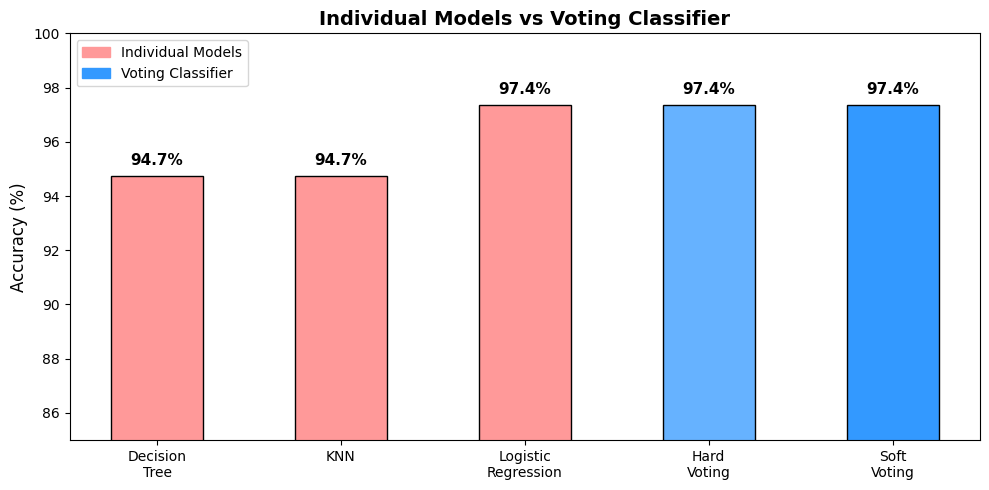


💡 Key Insight: Combining models gives better accuracy than individuals!


In [15]:
# ── Visualize: Individual vs Voting ──

models = ['Decision\nTree', 'KNN', 'Logistic\nRegression', 'Hard\nVoting', 'Soft\nVoting']
accuracies = [dt_acc, knn_acc, lr_acc, hard_acc, soft_acc]
colors = ['#FF9999', '#FF9999', '#FF9999', '#66B2FF', '#3399FF']

plt.figure(figsize=(10, 5))
bars = plt.bar(models, [a * 100 for a in accuracies], color=colors, edgecolor='black', width=0.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(85, 100)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Individual Models vs Voting Classifier', fontsize=14, fontweight='bold')

red_patch  = mpatches.Patch(color='#FF9999', label='Individual Models')
blue_patch = mpatches.Patch(color='#3399FF', label='Voting Classifier')
plt.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Combining models gives better accuracy than individuals!")

---
# 🌲 PART 2: Random Forest

## The Idea

Random Forest is like an **entire forest** of Decision Trees. But with two twists:

### Twist 1: Bagging (Bootstrap Aggregating)
> Each tree trains on a **random sample** of the data (with replacement). So every tree sees slightly different data.

### Twist 2: Random Feature Selection
> Each tree only looks at a **random subset of features** at each split. So trees are diverse!

```
Original Data (569 patients)
        │
   ┌────┴──────────────────┐
   │                       │
Random Sample 1      Random Sample 2  ...  Random Sample N
(400 patients,       (400 patients,
 15 features)         12 features)
   │                       │
Tree 1                  Tree 2          ...  Tree N
   │                       │
   └─────────── Vote ───────┘
                  │
            Final Prediction
```

**Why random?** → Diverse trees make fewer correlated errors → Better together!

In [16]:
# ── Train Random Forest ──

rf = RandomForestClassifier(
    n_estimators=100,   # Number of trees in the forest
    max_depth=None,     # Trees grow until pure (no limit)
    random_state=42
)

rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"🌲 Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print()
print("📋 Full Report:")
print(classification_report(y_test, rf_pred, target_names=['Malignant', 'Benign']))

🌲 Random Forest Accuracy: 0.9649 (96.49%)

📋 Full Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



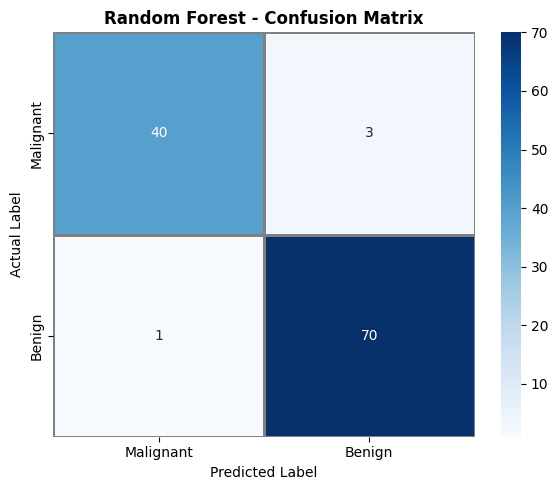


📖 How to read:
   Top-left  → Predicted Malignant, Actually Malignant (Correct ✅)
   Top-right → Predicted Benign, Actually Malignant (Wrong ❌ - dangerous!)
   Bot-left  → Predicted Malignant, Actually Benign (Wrong ❌)
   Bot-right → Predicted Benign, Actually Benign (Correct ✅)


In [17]:
# ── Confusion Matrix ──
# Shows us what the model got RIGHT and WRONG

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            linewidths=1, linecolor='gray')
plt.title('Random Forest - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print("\n📖 How to read:")
print("   Top-left  → Predicted Malignant, Actually Malignant (Correct ✅)")
print("   Top-right → Predicted Benign, Actually Malignant (Wrong ❌ - dangerous!)")
print("   Bot-left  → Predicted Malignant, Actually Benign (Wrong ❌)")
print("   Bot-right → Predicted Benign, Actually Benign (Correct ✅)")

---
## 🔍 Feature Importance

A big advantage of Random Forest: it tells us **which features matter the most!**

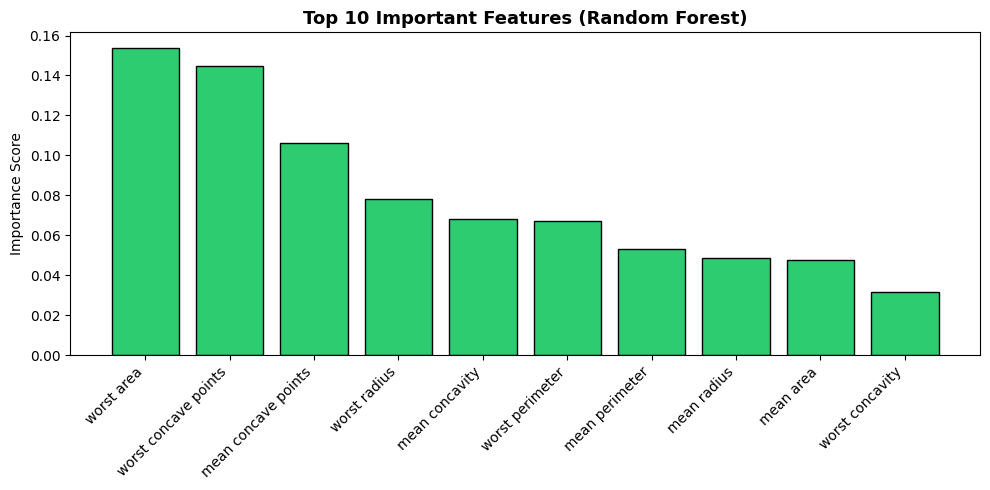

💡 Higher score = Feature is more useful for prediction

🏆 Most important feature: worst area


In [18]:
# Get feature importances from the trained Random Forest
importances = rf.feature_importances_
feature_names = data.feature_names

# Sort by importance
indices = np.argsort(importances)[::-1]

# Plot top 10 features
top_n = 10
plt.figure(figsize=(10, 5))
plt.bar(range(top_n),
        importances[indices[:top_n]],
        color='#2ecc71', edgecolor='black')
plt.xticks(range(top_n),
           [feature_names[i] for i in indices[:top_n]],
           rotation=45, ha='right')
plt.title('Top 10 Important Features (Random Forest)', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("💡 Higher score = Feature is more useful for prediction")
print(f"\n🏆 Most important feature: {feature_names[indices[0]]}")

---
## 🌳 How Number of Trees Affects Accuracy

   Trees:   1 → Accuracy: 93.86%
   Trees:   5 → Accuracy: 94.74%
   Trees:  10 → Accuracy: 95.61%
   Trees:  20 → Accuracy: 96.49%
   Trees:  50 → Accuracy: 96.49%
   Trees: 100 → Accuracy: 96.49%
   Trees: 200 → Accuracy: 96.49%


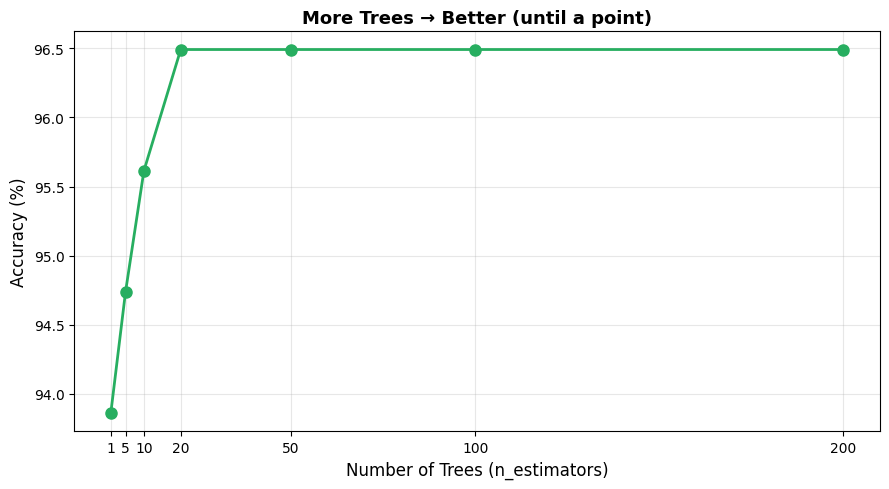


💡 After ~100 trees, accuracy stabilizes. Adding more trees costs time but gives no big gain.


In [19]:
# Let's see what happens as we add more trees
tree_counts = [1, 5, 10, 20, 50, 100, 200]
accuracies_per_count = []

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies_per_count.append(acc * 100)
    print(f"   Trees: {n:>3} → Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(9, 5))
plt.plot(tree_counts, accuracies_per_count, 'o-', color='#27ae60', linewidth=2, markersize=8)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('More Trees → Better (until a point)', fontsize=13, fontweight='bold')
plt.xticks(tree_counts)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 After ~100 trees, accuracy stabilizes. Adding more trees costs time but gives no big gain.")

---
# 📊 Final Comparison: All Models

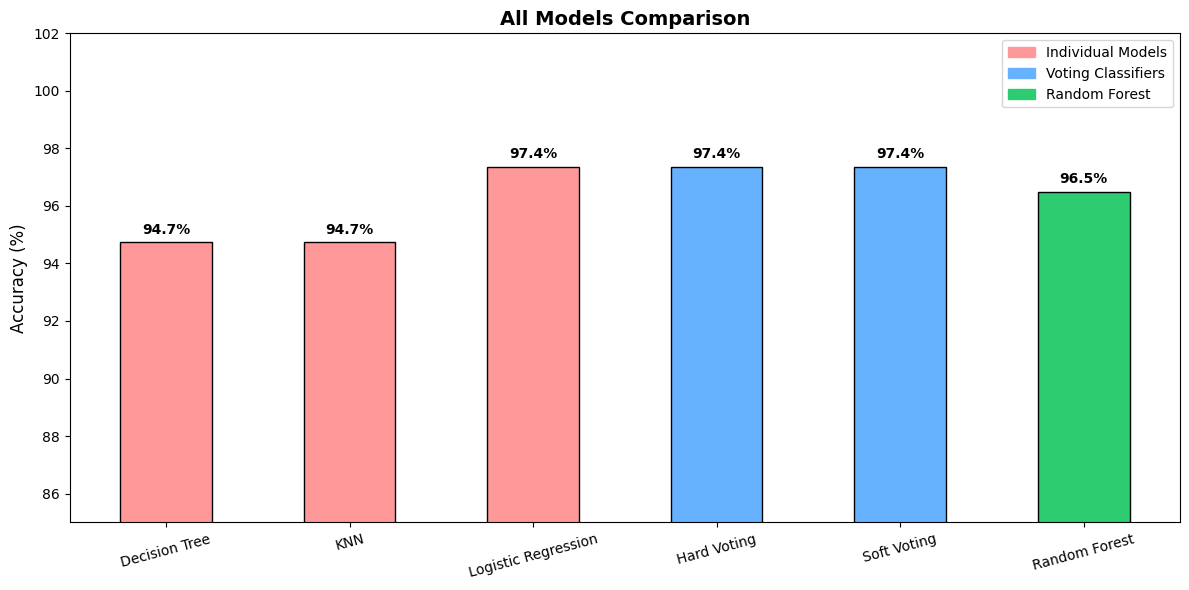


📋 Summary Table
----------------------------------------
Model                       Accuracy
----------------------------------------
Logistic Regression           97.37%
Hard Voting                   97.37%
Soft Voting                   97.37%
Random Forest                 96.49%
Decision Tree                 94.74%
KNN                           94.74%
----------------------------------------


In [20]:
# Compare everything side by side
results = {
    'Decision Tree': dt_acc,
    'KNN': knn_acc,
    'Logistic Regression': lr_acc,
    'Hard Voting': hard_acc,
    'Soft Voting': soft_acc,
    'Random Forest': rf_acc
}

colors = ['#FF9999', '#FF9999', '#FF9999', '#66B2FF', '#66B2FF', '#2ecc71']

plt.figure(figsize=(12, 6))
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(85, 102)
plt.xticks(rotation=15)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('All Models Comparison', fontsize=14, fontweight='bold')

legend_items = [
    mpatches.Patch(color='#FF9999', label='Individual Models'),
    mpatches.Patch(color='#66B2FF', label='Voting Classifiers'),
    mpatches.Patch(color='#2ecc71', label='Random Forest')
]
plt.legend(handles=legend_items)
plt.tight_layout()
plt.show()

# Print summary table
print("\n📋 Summary Table")
print("-" * 40)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 40)
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<25} {acc*100:>9.2f}%")
print("-" * 40)

---
## 🧠 Key Takeaways

| Concept | Simple Explanation |
|---|---|
| **Ensemble** | Multiple models together > one single model |
| **Hard Voting** | Each model votes class label → majority wins |
| **Soft Voting** | Each model votes probability → average decides |
| **Random Forest** | Many diverse Decision Trees + vote = powerful! |
| **Feature Importance** | Random Forest tells you which features matter |
| **n_estimators** | More trees = more stable, but slower to train |

---

## 🏋️ Try It Yourself!

1. Change `n_estimators` in Random Forest to 10. Does accuracy drop?
2. Add `max_depth=3` to Random Forest. What changes?
3. Remove Logistic Regression from the Voting Classifier. Does accuracy go up or down?
4. Try `voting='soft'` vs `voting='hard'` — which is better on this dataset?